## Google colab GPU

In [1]:
# Colab: clone repo + add to path
import os
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/colinminini/LLM6G-Repository'
REPO_DIR = 'LLM6G-Repository'

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(['git', 'clone', REPO_URL])
    os.chdir(REPO_DIR)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
else:
    print('Repo clone skipped (not running in Colab).')

HAS_CUDA = False
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except Exception:
    pass

if IN_COLAB and HAS_CUDA:
    # Install dependencies only when running on Colab with GPU
    !pip -q install -U pip
    !pip -q install -r requirements.txt
    # Optional: verify GPU
    !nvidia-smi
else:
    print(f'GPU setup skipped (colab={IN_COLAB}, cuda={HAS_CUDA}).')


Repo clone skipped (not running in Colab).
GPU setup skipped (colab=False, cuda=False).


# Model Benchmarking (Coverage)

Train LSTM, DeepAR, and TFT on `data_1to7`, then fine-tune Chronos-2 on the same dataset. The summary reports one-sided q0.95 coverage on train/val/test and uses quantile training (q50, q95).


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise RuntimeError("Could not locate project root containing 'src/' and 'data/'.")


PROJECT_ROOT = _resolve_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.train_utils import train_all
from src.chronos2_finetune import (
    Chronos2FineTuneConfig,
    build_default_hyperparameters,
    load_splits_for_autogluon,
    run_chronos2_finetune,
    evaluate_chronos2_models,
)

MODEL_TYPES = ["lstm", "deepar"] # add , 'tft' if wanted
DATASET = "data_1to7"
SPLITS = ["train", "val", "test"]

CONTEXT_LENGTH = 48
FORECAST_LENGTH = 48
QUANTILES = (0.5, 0.95)
MAX_EPOCHS = 100
PATIENCE = 3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_HEADS = 4
COVERAGE_TARGET = 0.95 if 0.95 in QUANTILES else max(QUANTILES)

AUTOGLUON_TIME_LIMIT = 300  # seconds
AUTOGLUON_EVAL_METRIC = "MAE"
AUTOGLUON_FREQ = "s"  # synthetic regular cadence
AUTOGLUON_KNOWN_COVARIATES = []

RESULTS_DIR = PROJECT_ROOT / "results/benchmarks"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHRONOS2_CONFIG = Chronos2FineTuneConfig(
    dataset_base=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    freq=AUTOGLUON_FREQ,
    use_integer_timestamps=True,
    synthetic_start="2000-01-01 00:00:00",
    eval_metric=AUTOGLUON_EVAL_METRIC,
    time_limit=AUTOGLUON_TIME_LIMIT,
    known_covariates_names=AUTOGLUON_KNOWN_COVARIATES,
    results_dir=RESULTS_DIR,
    hyperparameters=build_default_hyperparameters(),
    # hyperparameters={"Chronos2": [
    #        {"ag_args": {"name_suffix": "ZeroShot"},
    #         "context_length": CONTEXT_LENGTH},
    #        {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"},
    #         "context_length": CONTEXT_LENGTH},
    #    ]},

)


## Train baseline models

This runs LSTM, DeepAR, and TFT on `data_1to7`. Coverage shown is the final epoch value returned by the trainer.


In [3]:
train_results, train_histories = train_all(
    MODEL_TYPES,
    DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
)

train_rows = []
for (dataset, model), metrics in train_results.items():
    for split, coverage in metrics.items():
        train_rows.append(
            {"dataset": dataset, "split": split, "model": model, "coverage": coverage}
        )

train_df = pd.DataFrame(train_rows)
train_pivot = train_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
train_pivot


Epoch 1/100 - train_loss=0.627 - train_rmse=3.627 - val_loss=0.928 - val_rmse=5.667 - test_loss=1.097 - test_rmse=6.540 
Epoch 2/100 - train_loss=0.539 - train_rmse=3.578 - val_loss=0.914 - val_rmse=5.470 - test_loss=1.032 - test_rmse=6.357 
Epoch 3/100 - train_loss=0.520 - train_rmse=3.220 - val_loss=0.834 - val_rmse=4.619 - test_loss=0.967 - test_rmse=5.406 
Epoch 4/100 - train_loss=0.502 - train_rmse=3.027 - val_loss=0.823 - val_rmse=4.579 - test_loss=0.935 - test_rmse=5.290 
Epoch 5/100 - train_loss=0.499 - train_rmse=3.029 - val_loss=0.829 - val_rmse=4.592 - test_loss=0.943 - test_rmse=5.436 
Epoch 6/100 - train_loss=0.498 - train_rmse=3.034 - val_loss=0.817 - val_rmse=4.550 - test_loss=0.920 - test_rmse=5.232 
Epoch 7/100 - train_loss=0.496 - train_rmse=3.026 - val_loss=0.818 - val_rmse=4.583 - test_loss=0.940 - test_rmse=5.232 
Epoch 8/100 - train_loss=0.494 - train_rmse=3.022 - val_loss=0.820 - val_rmse=4.602 - test_loss=0.925 - test_rmse=5.291 
Early stopping at epoch 9: train

'Final metrics'

,metric,value
0,train_loss,0.492
1,train_rmse,3.027
2,val_loss,0.814
3,val_rmse,4.615
4,train_q0.5,0.788
5,train_q0.95,0.196
6,val_q0.5,1.307
7,val_q0.95,0.322
8,train_coverage,0.950
9,val_coverage,0.922


Epoch 1/100 - train_loss=1.689 - train_rmse=2.559 - val_loss=2.124 - val_rmse=3.804 - test_loss=2.162 - test_rmse=4.232 
Epoch 2/100 - train_loss=1.569 - train_rmse=2.417 - val_loss=2.110 - val_rmse=3.778 - test_loss=2.138 - test_rmse=4.207 
Epoch 3/100 - train_loss=1.554 - train_rmse=2.400 - val_loss=2.101 - val_rmse=3.785 - test_loss=2.126 - test_rmse=4.206 
Epoch 4/100 - train_loss=1.529 - train_rmse=2.385 - val_loss=2.107 - val_rmse=3.764 - test_loss=2.104 - test_rmse=4.191 
Epoch 5/100 - train_loss=1.506 - train_rmse=2.378 - val_loss=2.252 - val_rmse=3.757 - test_loss=2.110 - test_rmse=4.227 
Early stopping at epoch 6: train_rmse=2.368, val_rmse=3.769, test_rmse=4.226


'Final metrics'

,metric,value
0,train_loss,1.474
1,train_rmse,2.368
2,val_loss,3.000
3,val_rmse,3.769
4,train_q0.5,0.747
5,train_q0.95,0.168
6,val_q0.5,1.261
7,val_q0.95,0.281
8,train_coverage,0.947
9,val_coverage,0.952


model              deepar      lstm
dataset   split                    
data_1to7 test   0.945894  0.908769
          train  0.946679  0.949633
          val    0.952350  0.921560

## AutoGluon Chronos-2 fine-tuning

We fine-tune Chronos-2 using AutoGluon TimeSeries with a zero-shot and fine-tuned run.


In [4]:
train_data, val_data, test_data, data_freq = load_splits_for_autogluon(CHRONOS2_CONFIG)

predictor, model_names, leaderboard = run_chronos2_finetune(
    CHRONOS2_CONFIG,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    freq=data_freq,
)

autogluon_df = evaluate_chronos2_models(
    predictor,
    model_names=model_names,
    splits={"train": train_data, "val": val_data, "test": test_data},
    dataset_label=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
)

autogluon_coverage_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
autogluon_mae_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="mae"
).sort_index()

autogluon_coverage_pivot, autogluon_mae_pivot, leaderboard


Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/benchmarks/autogluon_data_1to7_v2'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:54:55 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.23 GB / 16.00 GB (38.9%)
Disk Space Avail:   325.50 GB / 460.43 GB (70.7%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MAE,
 'freq': 's',
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'}},
                                  {'ag_args': {'name_suffix': 'FineTuned'},
                      

Predictor path already existed, using a new run directory: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/benchmarks/autogluon_data_1to7_v2


	-2.7173       = Validation score (-MAE)
	1.43    s     = Training runtime
	1.15    s     = Validation (prediction) runtime
Training timeseries model Chronos2FineTuned. Training for up to 297.4s of the 297.4s of remaining time.
	-2.7340       = Validation score (-MAE)
	271.93  s     = Training runtime
	0.43    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'Chronos2FineTuned']
Total runtime: 274.97 s
Best model: Chronos2ZeroShot
Best model score: -2.7173
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


(model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      0.882267                    0.849564
           train                     0.974806                    0.961725
           val                       0.882994                    0.860223,
 model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      3.126521                    3.135980
           train                     2.411418                    2.405344
           val                       2.710753                    2.717338,
                model  score_test  score_val  pred_time_test  pred_time_val  \
 0  Chronos2FineTuned   -3.126521  -2.734045        0.811432       0.432723   
 1   Chronos2ZeroShot   -3.135980  -2.717338        0.856152       1.149575   
 
    fit_time_margin

## Coverage and MAE comparison summary

This table and plot compare one-sided q0.95 coverage across train/val/test for all models.
The AutoGluon tables above include both coverage and MAE for Chronos-2
ZeroShot vs FineTuned.


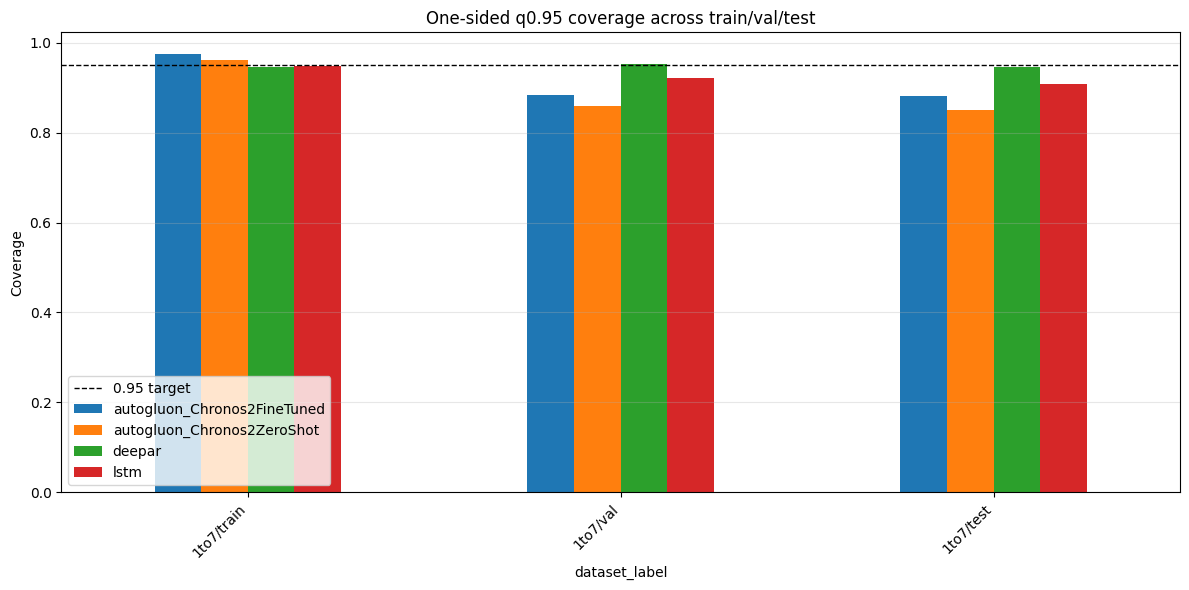

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/benchmark_train_models_display_coverage.png


model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
dataset   split                                                         
data_1to7 test                      3.126521                    3.135980
          train                     2.411418                    2.405344
          val                       2.710753                    2.717338

In [5]:
summary_df = pd.concat(
    [train_df, autogluon_df[["dataset", "split", "model", "coverage"]]],
    ignore_index=True,
)
summary_df["dataset_label"] = summary_df["dataset"].str.replace("data_", "") + "/" + summary_df["split"]
order = [
    "1to7/train",
    "1to7/val",
    "1to7/test",
]

summary_pivot = summary_df.pivot_table(
    index="dataset_label", columns="model", values="coverage"
).reindex(order)
summary_pivot  # type: ignore

ax = summary_pivot.plot(kind="bar", figsize=(12, 6))
ax.axhline(COVERAGE_TARGET, color="black", linestyle="--", linewidth=1, label=f"{COVERAGE_TARGET:.2f} target")
ax.set_ylabel("Coverage")
ax.set_title("One-sided q0.95 coverage across train/val/test")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
PLOTS_DIR = PROJECT_ROOT / "results/plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
benchmark_plot_path = PLOTS_DIR / "benchmark_train_models_display_coverage.png"
plt.savefig(benchmark_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved plot:", benchmark_plot_path)

autogluon_mae_pivot
